In [4]:
import kagglehub

In [5]:
path = kagglehub.dataset_download("saurav9786/indian-premier-league-match-analysis")
print("Path to dataset files:", path)

100%|██████████| 16.5k/16.5k [00:00<00:00, 25.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saurav9786/indian-premier-league-match-analysis/versions/1


In [7]:
from google.colab import files
uploaded = files.upload()

Saving matches.csv to matches.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
ipl_df = pd.read_csv("matches.csv")
ipl_df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [12]:
Sum_train = ipl_df.isnull().sum()
Percentage = ( ipl_df.isnull().sum()/ipl_df.isnull().count())
pd.concat([Sum_train,Percentage], axis =1, keys= ['Sum', 'Percentage'])

,Sum,Percentage
id,0,0.000000
season,0,0.000000
city,7,0.011006
date,0,0.000000
team1,0,0.000000
team2,0,0.000000
toss_winner,0,0.000000
toss_decision,0,0.000000
result,0,0.000000
dl_applied,0,0.000000


In [13]:
ipl_df.drop(['umpire3'], axis=1,inplace=True)

In [14]:
ipl_df.dropna(inplace=True)

In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv("matches.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['winner'] = df['winner'].fillna("No Result")
df['player_of_match'] = df['player_of_match'].fillna("Unknown")

for col in ['umpire1', 'umpire2', 'umpire3']:
    df[col] = df[col].fillna("Unknown")

df['win_by_runs'] = pd.to_numeric(df['win_by_runs'], errors='coerce').fillna(0)
df['win_by_wickets'] = pd.to_numeric(df['win_by_wickets'], errors='coerce').fillna(0)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               636 non-null    int64         
 1   season           636 non-null    int64         
 2   city             629 non-null    object        
 3   date             235 non-null    datetime64[ns]
 4   team1            636 non-null    object        
 5   team2            636 non-null    object        
 6   toss_winner      636 non-null    object        
 7   toss_decision    636 non-null    object        
 8   result           636 non-null    object        
 9   dl_applied       636 non-null    int64         
 10  winner           636 non-null    object        
 11  win_by_runs      636 non-null    int64         
 12  win_by_wickets   636 non-null    int64         
 13  player_of_match  636 non-null    object        
 14  venue            636 non-null    object   

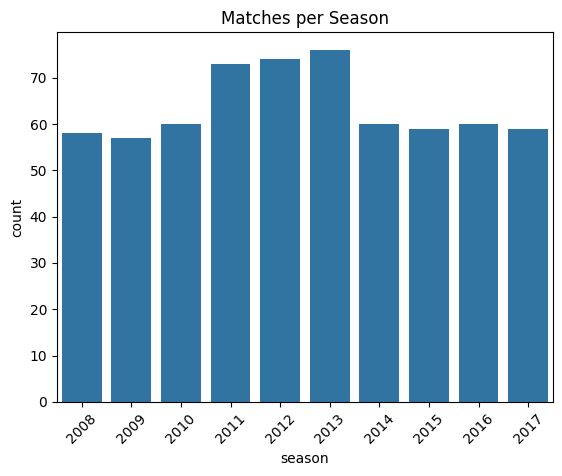

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='season', data=df)
plt.title("Matches per Season")
plt.xticks(rotation=45)
plt.show()

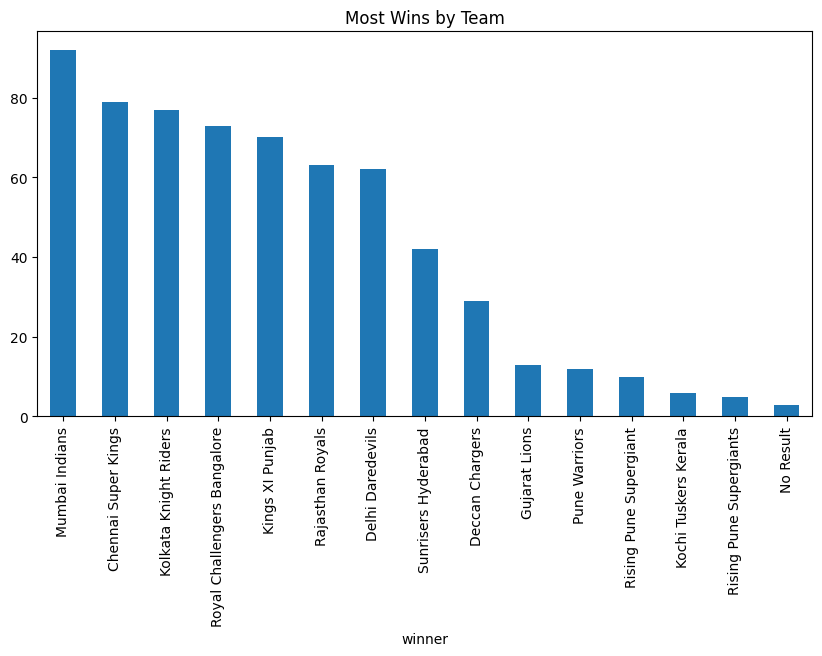

In [36]:
wins = df['winner'].value_counts()
wins.plot(kind='bar', figsize=(10,5), title="Most Wins by Team")
plt.show()

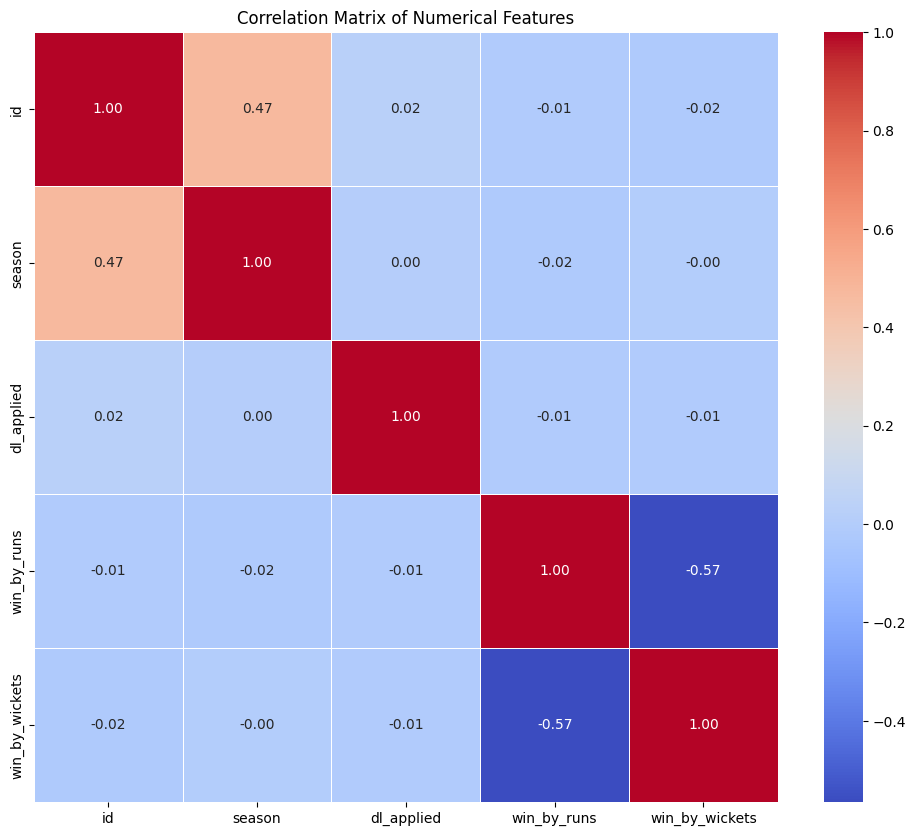

In [37]:
numerical_df = df.select_dtypes(include=[np.number])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [38]:
df['toss_win_match'] = (df['toss_winner'] == df['winner']).astype(int)

df_encoded = df.copy()

categorical_cols = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols)

df_encoded['winner'] = df_encoded['winner'].astype('category').cat.codes

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df_encoded['result'] = df_encoded['result'].astype('category').cat.codes

columns_to_drop = ['id', 'date', 'player_of_match', 'umpire1', 'umpire2', 'umpire3', 'winner']
X = df_encoded.drop(columns=columns_to_drop)
y = df_encoded['winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.90625


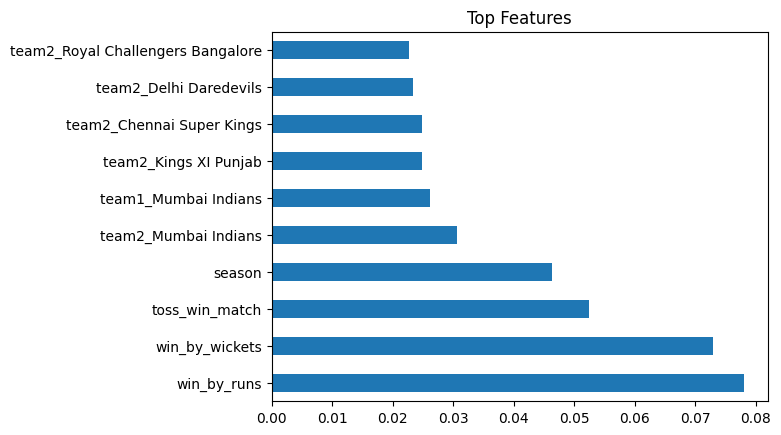

In [40]:
importances = rf.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(10)

feat_imp.plot(kind='barh', title="Top Features")
plt.show()

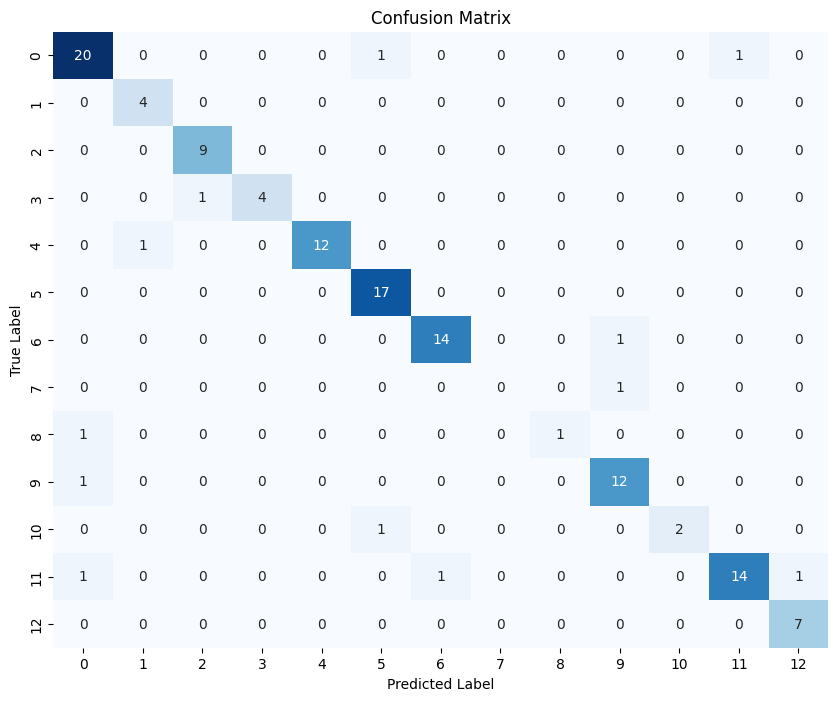


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        22
           1       0.80      1.00      0.89         4
           2       0.90      1.00      0.95         9
           3       1.00      0.80      0.89         5
           4       1.00      0.92      0.96        13
           6       0.89      1.00      0.94        17
           7       0.93      0.93      0.93        15
           8       0.00      0.00      0.00         1
           9       1.00      0.50      0.67         2
          10       0.86      0.92      0.89        13
          11       1.00      0.67      0.80         3
          13       0.93      0.82      0.88        17
          14       0.88      1.00      0.93         7

    accuracy                           0.91       128
   macro avg       0.85      0.81      0.82       128
weighted avg       0.90      0.91      0.90       128



In [41]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

#### Logistic Regression for Model Comparison

In [42]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.5625

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68        22
           1       0.00      0.00      0.00         4
           2       0.38      0.67      0.48         9
           3       0.00      0.00      0.00         5
           4       0.47      0.54      0.50        13
           6       0.62      0.76      0.68        17
           7       0.61      0.73      0.67        15
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          10       0.80      0.62      0.70        13
          11       0.00      0.00      0.00         3
          13       0.58      0.65      0.61        17
          14       0.20      0.14      0.17         7

    accuracy                           0.56       128
   macro avg       0.33      0.37      0.35       128
weighted avg       0.51      0.56      0.53       128

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
